## Introduction

This notebook explores the dataset, focusing on understanding its structure and content. We'll:
- Load and examine the data
- Identify assumptions and potential issues
- Detect missing data
- Visualize the data's basic spread
- Inform future exploration and improvement strategies

In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#import view and validate the dataset
dataset = pd.read_excel('../data/botswana_bank_customer_churn.xlsx')
print(dataset.head())
dataset.shape

  Date of Birth  Gender Marital Status  Number of Dependents  \
0    1987-08-29    Male       Divorced                     3   
1    2000-02-07  Female        Married                     1   
2    1954-02-03  Female         Single                     1   
3    1991-01-15  Female       Divorced                     5   
4    1992-04-08  Female       Divorced                     2   

                        Occupation    Income Education Level  Customer Tenure  \
0      Information systems manager  77710.14     High School               30   
1               Charity fundraiser  58209.87     High School               27   
2  Television production assistant   9794.01     High School               14   
3            Agricultural engineer  15088.98     High School               23   
4         Teacher, early years/pre  60726.56        Master's               22   

  Customer Segment Preferred Communication Channel  Credit Score  \
0           Retail                           Phone          

(115640, 19)

## About dataset

This synthetic dataset contains customer information from a fictional bank in Botswana, designed to analyze customer churn. It comprises 115,640 records, each row representing a unique customer. Unique identifiers such as name, surname, address, and index have been removed as they are not relevant to this study. The original dataset can be found on Kaggle [Original dataset](https://www.kaggle.com/datasets/sandiledesmondmfazi/bank-customer-churn). The data is uniformly distributed across categories, with each field complete except for "Churn Reason" and "Churn Date", which have 88% missing data.

 

**Note**
For simplicity, the study assumes a 1:1 exchange rate between Botswana Pula (BWP) and South African Rand (ZAR).

In [ ]:
#convert date of birth to age
from datetime import datetime
from dateutil.relativedelta import relativedelta
dataset['Date of Birth'] = pd.to_datetime(dataset['Date of Birth'])
dataset["Age"] = dataset['Date of Birth'].apply(lambda x: relativedelta(datetime.now(), x).years)
dataset.drop('Date of Birth', axis=1, inplace=True)


,Gender,Marital Status,Number of Dependents,Occupation,Income,Education Level,Customer Tenure,Customer Segment,Preferred Communication Channel,Credit Score,Credit History Length,Outstanding Loans,Churn Flag,Churn Reason,Churn Date,Balance,NumOfProducts,NumComplaints,Age
0,Male,Divorced,3,Information systems manager,77710.14,High School,30,Retail,Phone,397,24,41959.74,0,NaN,NaT,211359.05,1,0,38
1,Female,Married,1,Charity fundraiser,58209.87,High School,27,SME,Email,665,10,8916.67,0,NaN,NaT,30624.76,4,1,26
2,Female,Single,1,Television production assistant,9794.01,High School,14,Retail,Email,715,21,43270.54,0,NaN,NaT,111956.61,2,6,72
3,Female,Divorced,5,Agricultural engineer,15088.98,High School,23,Corporate,Phone,747,17,17887.65,0,NaN,NaT,201187.61,1,0,35
4,Female,Divorced,2,"Teacher, early years/pre",60726.56,Master's,22,Corporate,Email,549,25,32686.84,0,NaN,NaT,60391.24,5,6,33


In [ ]:
# Charn binary column
dataset['Churn'] = dataset['Churn Date'].apply(lambda x: 0 if pd.isnull(x) else 1)
columns = [
    'Gender', 'Marital Status', 'Number of Dependents', 'Occupation',
    'Income', 'Education Level', 'Customer Tenure', 'Customer Segment',
    'Preferred Communication Channel', 'Credit Score',
    'Credit History Length', 'Outstanding Loans', 'Churn Flag',
    'Churn Reason', 'Churn Date', 'Balance', 'NumOfProducts',
    'NumComplaints', 'Age'
]

dataset_with_churn = dataset.loc[dataset['Churn'] == 1, columns]


(14094, 19)

In [5]:
churn_flagged_count = (dataset_with_churn['Churn Flag'] == 1).sum()
print(f"Number of rows with Churn Flag = 1: {churn_flagged_count}")

reason_counts = dataset_with_churn['Churn Reason'].value_counts()
print(reason_counts)

total_reason_count = reason_counts.sum()
print(f"Total number of rows with Churn Reason: {total_reason_count}")


Number of rows with Churn Flag = 1: 14094
Churn Reason
Service Issues             3573
Account Closure            3548
Relocation                 3528
Better Offers Elsewhere    3445
Name: count, dtype: int64
Total number of rows with Churn Reason: 14094


#### Observation

Given the data patterns, it's evident that flagged customers ultimately churn. Moving forward, we'll assume all flagged customers leave the bank, while non-flagged customers remain. This addresses the missing data issue in "Churn Date" and "Churn Reason" fields.

In [ ]:
dataset_v2 = dataset.copy()

#drop that are not needed or have incomplete data
dataset_v2.drop(['Churn Date', 'Churn', 'Churn Reason', 'Occupation'], axis=1, inplace=True)
dataset_v2.rename(columns={'Churn Flag': 'Churned'}, inplace=True)
dataset_v2['Churned'] =dataset_v2['Churned'].apply(lambda x: 'Yes' if x == 1 else 'No')


## Preprocessing data
Scaling continueous and encode Catergorical variables

In [8]:
categoric_cols= ["Gender","Marital Status","Education Level","Customer Segment","Preferred Communication Channel","Occupation"]
continuous_cols= [col for col in dataset_v2.columns if col not in categoric_cols]
continuous_cols.remove('Churned')
print(continuous_cols)

['Number of Dependents', 'Income', 'Customer Tenure', 'Credit Score', 'Credit History Length', 'Outstanding Loans', 'Balance', 'NumOfProducts', 'NumComplaints', 'Age']


In [9]:
##Scaling
from sklearn.preprocessing import StandardScaler
# StandardScaler
scaler = StandardScaler()

for col in continuous_cols:
    dataset_v2[col] = scaler.fit_transform(dataset_v2[[col]])

print(dataset_v2[continuous_cols].head())

   Number of Dependents    Income  Customer Tenure  Credit Score  \
0              0.291158  0.913930         1.676578     -1.114625   
1             -0.880322  0.203011         1.329925      0.570202   
2             -0.880322 -1.562082        -0.172239      0.884535   
3              1.462638 -1.369044         0.867720      1.085709   
4             -0.294582  0.294761         0.752169     -0.159051   

   Credit History Length  Outstanding Loans   Balance  NumOfProducts  \
0               0.976753           1.164867  1.200937      -1.416563   
1              -0.640885          -1.174002 -1.301956       0.709054   
2               0.630116           1.257649 -0.175635      -0.708024   
3               0.167934          -0.539014  1.060078      -1.416563   
4               1.092298           0.508509 -0.889736       1.417593   

   NumComplaints       Age  
0      -1.580025 -0.599413  
1      -1.263496 -1.317378  
2       0.319148  1.434821  
3      -1.580025 -0.778904  
4       0.319

In [10]:
## Encoding
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder

# Label Encoding
le = LabelEncoder()
dataset_v2['Gender'] = le.fit_transform(dataset_v2['Gender'])
dataset_v2['Churned'] = le.fit_transform(dataset_v2['Churned'])

# One-Hot Encoding
df_encoded = pd.get_dummies(dataset_v2[['Marital Status','Customer Segment', 'Preferred Communication Channel']])
dataset_v2 = pd.concat([dataset_v2.drop(['Marital Status','Customer Segment', 'Preferred Communication Channel'], axis=1), df_encoded], axis=1)
#Ordinal Encoding
ordinal_encoder = OrdinalEncoder(categories=[['High School', "Master's", "Bachelor's", 'Diploma']])
dataset_v2['Education Level'] = ordinal_encoder.fit_transform(dataset_v2[['Education Level']])

In [ ]:
dummy_cols = ['Customer Segment_Corporate', 'Customer Segment_Retail', 'Customer Segment_SME','Preferred Communication Channel_Email', 'Preferred Communication Channel_Phone','Marital Status_Divorced', 'Marital Status_Married', 'Marital Status_Single']

for col in dummy_cols:
    dataset_v2[col] = dataset_v2[col].apply(lambda x: 1 if x == True else 0)

In [ ]:
dataset_v2.to_csv('preprocessed_data.csv', index=False)
dataset_v2.head()
dataset_v2.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115640 entries, 0 to 115639
Data columns (total 21 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   Gender                                 115640 non-null  int64  
 1   Number of Dependents                   115640 non-null  float64
 2   Income                                 115640 non-null  float64
 3   Education Level                        115640 non-null  float64
 4   Customer Tenure                        115640 non-null  float64
 5   Credit Score                           115640 non-null  float64
 6   Credit History Length                  115640 non-null  float64
 7   Outstanding Loans                      115640 non-null  float64
 8   Churned                                115640 non-null  int64  
 9   Balance                                115640 non-null  float64
 10  NumOfProducts                          115640 non-null  

## Data exploration

We'll dive into the data to understand its characteristics.

- **Univariate Analysis**
We'll perform univariate analysis on income, balance, and outstanding loans to identify outliers and confirm the data's symmetry around a central point.

- **Correlation Analysis**
Next, we'll create a correlation heatmap to check for multicollinearity and potential redundancy of information.

- **Data Visualisation**
Finally, we'll visualise the data using T-SNE plot to identify natural clusters and inform our choice of predictive model.

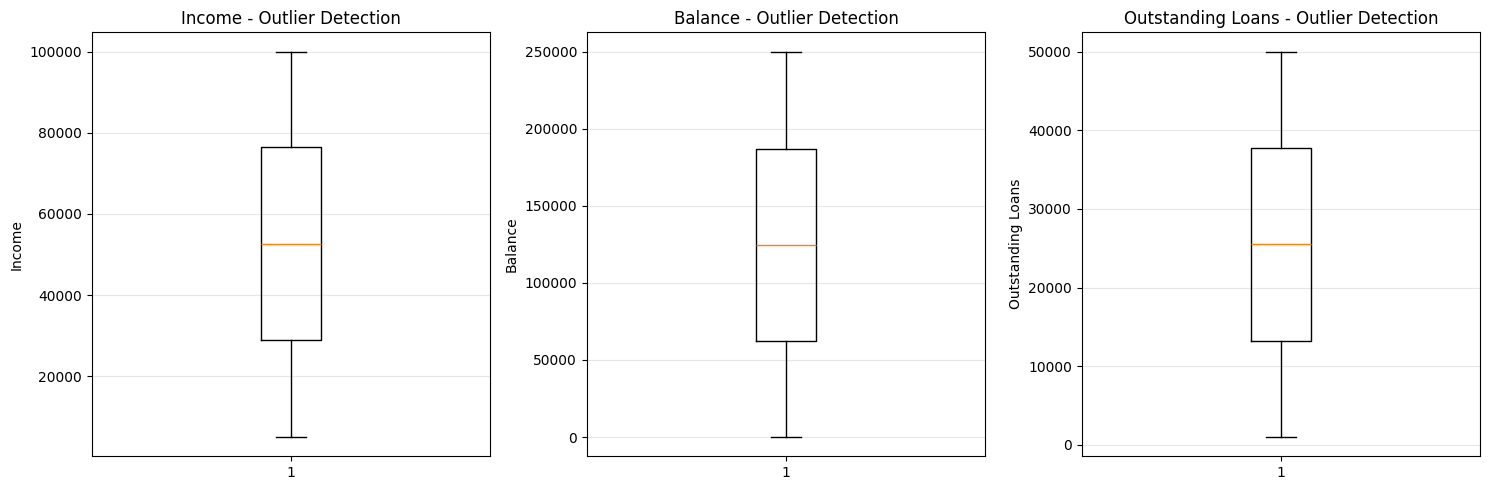

In [13]:
# Box plots to spot outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Income box plot
axes[0].boxplot(dataset['Income'].dropna())
axes[0].set_title('Income - Outlier Detection')
axes[0].set_ylabel('Income')
axes[0].grid(axis='y', alpha=0.3)

# Balance box plot
axes[1].boxplot(dataset['Balance'].dropna())
axes[1].set_title('Balance - Outlier Detection')
axes[1].set_ylabel('Balance')
axes[1].grid(axis='y', alpha=0.3)

# Outstanding Loans box plot
axes[2].boxplot(dataset['Outstanding Loans'].dropna())
axes[2].set_title('Outstanding Loans - Outlier Detection')
axes[2].set_ylabel('Outstanding Loans')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### Observation

The univariate analysis reveals an **absence of outliers**, with income, balance, and outstanding loans exhibiting near-perfect symmetry. While this might seem ideal, it's unusual for financial data, which often contains extreme values. This could potentially lead to issues down the line.

Notably, the data shows a **high liquidity ratio,** and the maximum loan amount is **roughly half** of the maximum income amount, indicating conservative lending practices.

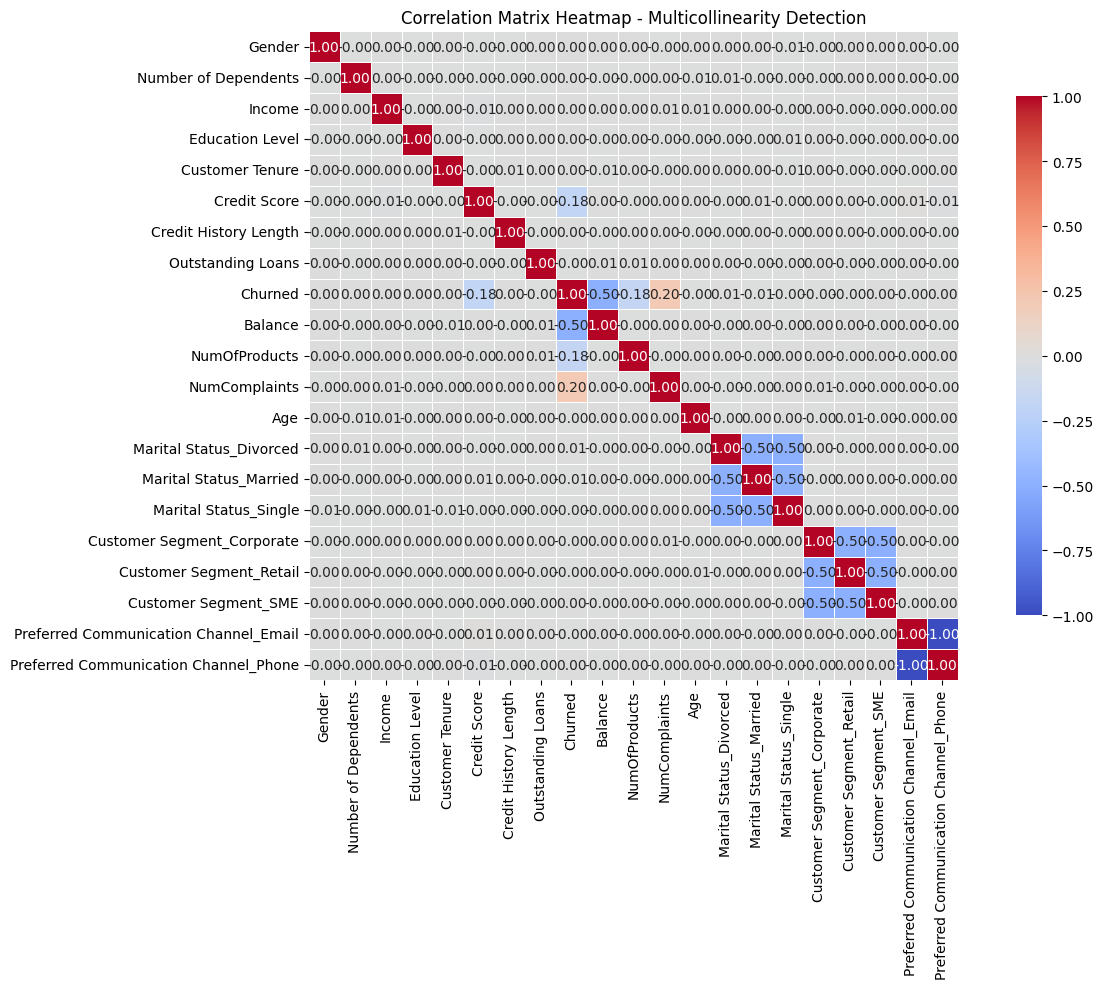

In [14]:
# Correlation heatmap for multicollinearity detection
correlation_matrix = dataset_v2.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix Heatmap - Multicollinearity Detection')
plt.tight_layout()
plt.show()

#### Observations

- **Drivers of customer churn:**
    - Balance: negatively correlated (-0.5) - customers with higher balances are less likely to churn
    - Number of complaints: weak positive correlation (0.2) - customers with more complaints are more likely to churn
    - Number of products: negative correlation (-0.18) - customers with more products are less likely to churn
    - Credit score: weak negative correlation (-0.18) - customers with higher credit scores are less likely to churn

- **Structural correlations:**
    - Prefab communication channels have a binary relationship
    - Nairoto status and customer segments have correlations due to one-hot encoding (~0.5)

- **Unexpected lack of correlations:**
    - Income is not correlated with credit score, outstanding loans, education level, age, or customer tenure (expected correlations in real-life data)
This synthetic data may not accurately represent real-life patterns, potentially impacting model performance on real data.

Computing t-SNE... this may take a moment


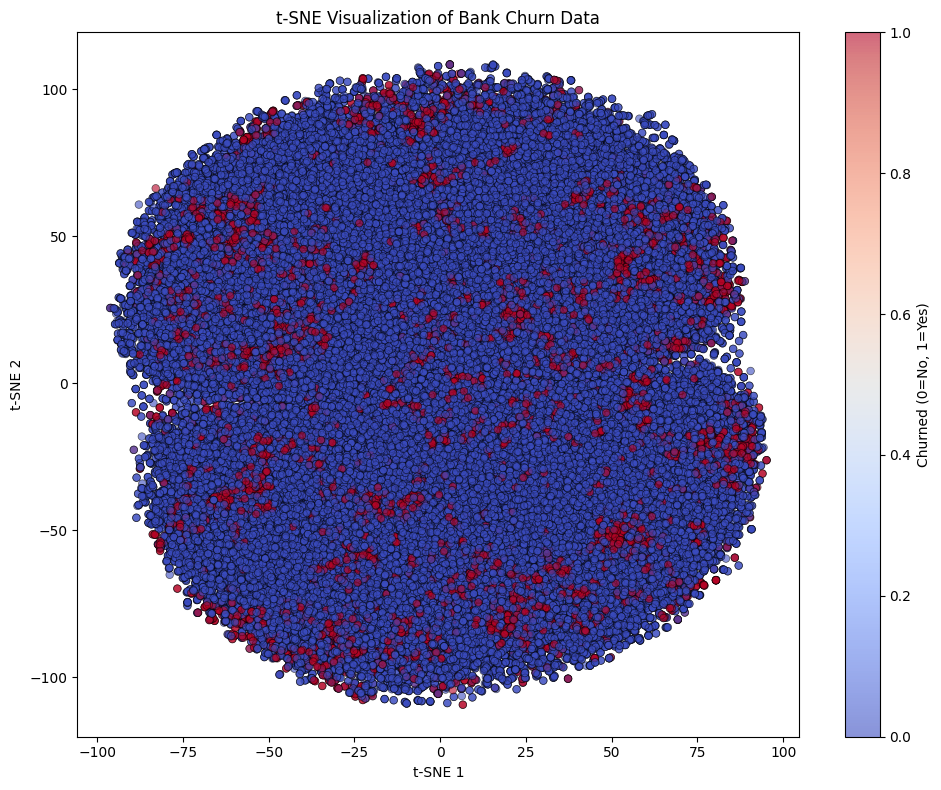

t-SNE complete!


In [15]:
# Sample down first — critical at your data size
dataset_v2_sample = dataset_v2.sample(11564, random_state=42)

labels = dataset_v2_sample['Churned']


# Apply t-SNE
print("Computing t-SNE... this may take a moment")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(dataset_v2.drop('Churned', axis=1))


# Plot
# Create scatter plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=dataset_v2['Churned'], 
                      cmap='coolwarm', alpha=0.6, s=30, edgecolors='k', linewidth=0.5)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE Visualization of Bank Churn Data')
cbar = plt.colorbar(scatter)
cbar.set_label('Churned (0=No, 1=Yes)')
plt.tight_layout()
plt.show()

print("t-SNE complete!")

The t-SNE plot shows blue (stayed) and red (churned) points are heavily intermingled, indicating:
- No clear separation of churners, suggesting no single profile defines them
- Small, dense pockets of red points (micro-clusters) represent specific subgroups with high churn rates (e.g., high-complaint, low-balance customers)
- Simple linear models may struggle; non-linear approaches like Random Forest or XGBoost are likely needed to capture nuances in overlapping regions.

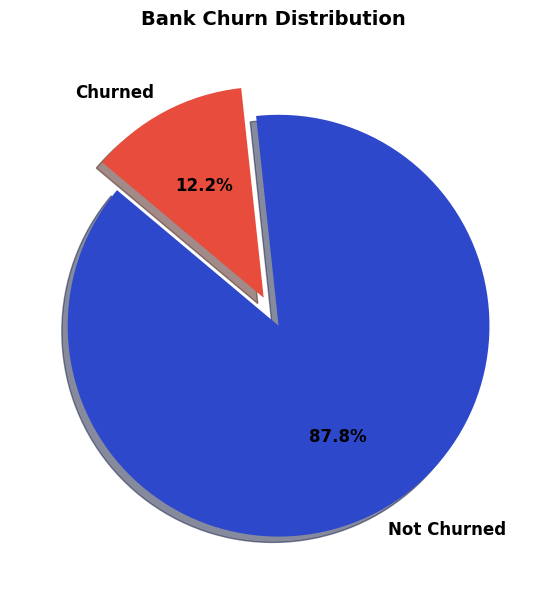


Churn Summary:
Not Churned: 101546 customers (87.8%)
Churned: 14094 customers (12.2%)


In [18]:

# Pie chart for Churned vs Not Churned
churn_counts = dataset_v2['Churned'].value_counts()

# Map 0 and 1 to labels if encoded
labels = ['Not Churned', 'Churned']
sizes = [churn_counts.get(0, 0), churn_counts.get(1, 0)]
colors = ["#2e48cc", '#e74c3c']
explode = (0.05, 0.1)

plt.figure(figsize=(8, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140, textprops={'fontsize': 12, 'weight': 'bold'})
plt.title('Bank Churn Distribution', fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.show()

print(f"\nChurn Summary:")
print(f"Not Churned: {sizes[0]} customers ({sizes[0]/(sizes[0]+sizes[1])*100:.1f}%)")
print(f"Churned: {sizes[1]} customers ({sizes[1]/(sizes[0]+sizes[1])*100:.1f}%)")


There is a **Significant Class Imbalance**, the vast majority of customers stay with the bank. 

Churn Rate: Only $12.2\%$ of the total customer base has churned.

Retention Rate: $87.8\%$ of customers stay in the bank.

This heavy imbalance means that predictive models will likely be very good at identifying "safe" customers but may struggle to accurately pinpoint the smaller $12.2\%$ who are at risk without specific tuning.